# UNIVERSIDAD NACIONAL DE INGENIERÍA
## UNIDAD DE POSTGRADO FIIS

# PLAN DE TESIS
### Agente Inteligente para la Generación Automática de Queries MongoDB a partir de Lenguaje Natural

**Autor:** Anthony Jesús Portilla Cano
**Asesor:** ____________________
**Institución:** Prosegur
**Duración estimada:** Julio 2025 – Febrero 2026 (7 meses)

---

# Índice
1. Planteamiento del Problema
2. Objetivos
3. Marco Teórico y Estado del Arte
4. Metodología de Investigación
5. Administración del plan de tesis
6. Referencias Bibliográficas
7. Anexos

# 1. Planteamiento del Problema
## Diagnóstico
En Prosegur, los analistas convierten requerimientos funcionales en lenguaje natural en consultas MongoDB complejas. Este proceso es manual, lento y propenso a errores, generando riesgos operativos y altos costos. Una herramienta basada en IA podría reducir el tiempo y los errores, mitigando penalidades por incumplimiento de SLA.

## Antecedentes bibliográficos
- Text-to-SQL ampliamente estudiado, pero poco adaptado a NoSQL.
- Modelos como SmBoP y SMART abordan parsing semántico y generación de queries en MongoDB.
- Limitaciones en precisión y cobertura de operadores complejos.

## Formulación del Problema
**¿Cómo automatizar la generación de consultas MongoDB a partir de requerimientos escritos en lenguaje natural, reduciendo tiempo y errores?**
- Interpretar instrucciones técnicas en lenguaje natural.
- Transformar en queries MongoDB válidas y precisas.
- Validar la estructura antes de uso por analistas.

## Justificación y Alcances
- Reduce tiempo y costos operativos.
- Minimiza penalidades por errores.
- Alcance: Genera queries MongoDB válidas, exporta pipelines en formato .aggregate().

# 2. Objetivos
## Objetivo General
Diseñar y desarrollar un agente inteligente que genere automáticamente consultas MongoDB válidas y funcionales a partir de requerimientos en lenguaje natural.

## Objetivos Específicos
1. Interfaz de entrada para instrucciones técnicas.
2. Parsing semántico bottom-up (SmBoP).
3. Generación adaptada a MongoDB (SMART, prompt tuning).
4. Validación automática de sintaxis y estructura.
5. Exportación en formato .aggregate().

# 3. Marco Teórico y Estado del Arte
- Parsing semántico bottom-up (SmBoP).
- Traducción a NoSQL con prompt tuning (SMART).
- Metodologías Agile+AI y MLOps.
- Limitaciones de Text-to-SQL en NoSQL.
- Vacíos: cobertura de operadores complejos, validación semántica, integración con JSON.

# 4. Metodología de Investigación
- Enfoque Agile+AI, validación incremental.
- Parsing semántico bottom-up adaptado a MongoDB.
- Generación progresiva de queries con prompt tuning.
- Validación automática y manual.
- Métricas: exactitud estructural, cobertura de operadores, reducción de tiempo, feedback de analistas.

# 5. Administración del plan de tesis
- Cronograma de sprints.
- Presupuesto: Infraestructura Azure, API OpenAI, software open source.
- Financiamiento: autofinanciado por el autor.

# 6. Referencias Bibliográficas
- Hong et al. (2024)
- Lu et al. (2025)
- Ramachandran & Sarawagi (2024)
- Rubin & Berant (2021)
- Wang et al. (2020)
- Zhang et al. (2023)

# 7. Anexos
## Matriz de Consistencia
- Título: Agente Inteligente para la Generación Automática de Queries MongoDB a partir de Lenguaje Natural
- Problema General: ¿Cómo automatizar la generación de consultas MongoDB a partir de requerimientos en lenguaje natural, minimizando tiempo y errores?
- Objetivo General: Diseñar y desarrollar un agente inteligente que genere automáticamente consultas MongoDB desde lenguaje natural.
- Hipótesis General: Si se emplean técnicas de parsing semántico y modelos adaptados como SmBoP, es posible generar queries MongoDB válidas y precisas a partir de lenguaje natural, reduciendo significativamente el tiempo y errores del proceso manual.
- Variables: Independiente (lenguaje natural de entrada), Dependiente (query MongoDB generada: formato, precisión, validez).
- Metodología: Investigación tecnológica aplicada – diseño, implementación y validación experimental mediante parsing semántico y prompt tuning.
- Instrumentos de Validación: Testing de queries, verificación sintáctica, evaluación con usuarios expertos.
- Resultados esperados: Reducción del tiempo por solicitud (< 5 min), queries válidas y ejecutables, alto nivel de satisfacción de analistas.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import random
import os
import sys
sys.path.append(os.path.abspath("../src"))
from AgenteGeneradorQueryMongo import SmartMongoQueryGenerator

c:\Users\antho\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Corrección: asegurar correspondencia entre consultas y campos esperados
colecciones = ["clientes", "empleados", "productos", "ventas", "transactions_collection"]
consultas_campos = [
    ("cuenta cuántos empleados hay en cada departamento", ["empleado", "departamento"]),
    ("muestra los 5 productos más vendidos", ["producto", "ventas"]),
    ("une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta", ["nombre_cliente", "total_venta"]),
    ("lista los empleados por departamento", ["empleado", "departamento"]),
    ("calcula el total de ventas por producto", ["producto", "total_ventas"]),
    ("muestra los productos más vendidos", ["producto", "ventas"]),
    ("cuál es el cliente con más compras", ["cliente", "compras"]),
    ("lista los departamentos y su cantidad de empleados", ["departamento", "empleados"]),
    ("muestra el precio promedio de los productos", ["producto", "precio"]),
    ("cuenta cuántos clientes hay por ciudad", ["cliente", "ciudad"]),
    # ... puedes agregar más pares ...
]

instrucciones = []
for _ in range(100):
    col = random.choice(colecciones)
    consulta, campos_esp = random.choice(consultas_campos)
    instrucciones.append((col, consulta, campos_esp))

Top-k configuraciones por score semántico:


,trial,threshold,use_synonyms,cobertura,score
7,7,0.9,False,0.7,0.747
4,4,0.8,True,0.7,0.741
3,3,0.7,False,0.7,0.716
2,2,0.7,True,0.7,0.684
6,6,0.9,True,0.7,0.664


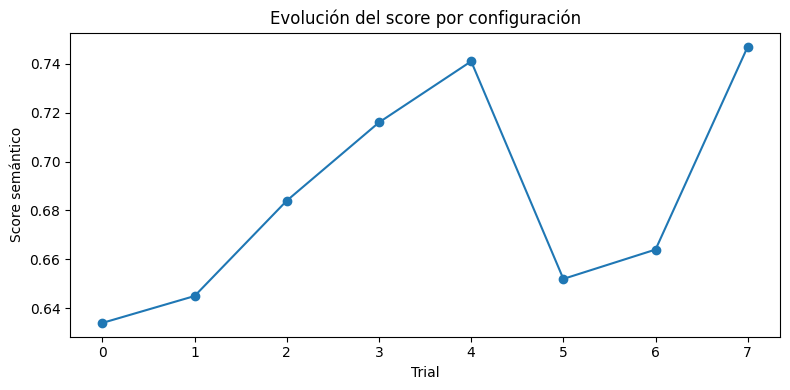

In [7]:
# Ejemplo de optimización de hiperparámetros (Random Search) y análisis de resultados para el agente generador de queries MongoDB
import pandas as pd
import matplotlib.pyplot as plt
import random
import re

# Diccionario de sinónimos ampliado y robusto
SINONIMOS = {
    "empleado": ["empleado", "empleados", "personal", "colaborador", "colaboradores", "trabajador", "trabajadores", "count", "cantidad_empleados", "n_empleados"],
    "ventas": ["ventas", "venta", "total_ventas", "total_venta", "vendidos", "total_vendidos", "importe", "monto", "cantidad_ventas", "n_ventas"],
    "nombre_cliente": ["nombre_cliente", "cliente_nombre", "nombre del cliente", "nombre", "cliente"],
    "total_venta": ["total_venta", "importe", "monto", "total", "valor_venta", "valor total"],
    "departamento": ["departamento", "departamentos", "area", "área", "sector", "division", "división"],
    "producto": ["producto", "productos", "articulo", "artículos", "item", "items", "mercancía", "mercancia"],
    "cliente": ["cliente", "clientes", "comprador", "compradores", "usuario", "usuarios"],
    "compras": ["compras", "compra", "adquisiciones", "adquisición", "transacciones"],
    "precio": ["precio", "precios", "valor", "costo", "coste", "importe"],
    "ciudad": ["ciudad", "ciudades", "localidad", "localidades", "municipio", "municipios"],
    "empleados": ["empleados", "empleado", "personal", "colaboradores", "trabajadores", "cantidad_empleados", "n_empleados"],
}

# Función de equivalencia mejorada: insensible a mayúsculas/minúsculas, plurales, y coincidencias parciales/sinónimos cruzados

def normaliza_campo(campo):
    campo = campo.lower().strip()
    campo = re.sub(r"[áàäâ]", "a", campo)
    campo = re.sub(r"[éèëê]", "e", campo)
    campo = re.sub(r"[íìïî]", "i", campo)
    campo = re.sub(r"[óòöô]", "o", campo)
    campo = re.sub(r"[úùüû]", "u", campo)
    campo = re.sub(r"[^a-z0-9_]", "", campo)
    return campo

def campos_equivalentes(c1, c2):
    c1n = normaliza_campo(c1)
    c2n = normaliza_campo(c2)
    # Sinónimos directos
    for key, sinonimos in SINONIMOS.items():
        sinonimos_norm = [normaliza_campo(s) for s in sinonimos]
        if c1n in sinonimos_norm and c2n in sinonimos_norm:
            return True
    # Coincidencia parcial
    if c1n in c2n or c2n in c1n:
        return True
    return False

# Definir espacio de hiperparámetros
param_space = [
    {'threshold': t, 'use_synonyms': s}
    for t in [0.6, 0.7, 0.8, 0.9]
    for s in [True, False]
    ]

# Simular ejemplos de instrucciones y campos esperados (corregido: correspondencia robusta)
colecciones = ["empleados", "productos", "ventas", "clientes", "departamentos"]
consultas_campos = [
    ("cuenta cuántos empleados hay en cada departamento", ["empleado", "departamento"]),
    ("muestra los 5 productos más vendidos", ["producto", "ventas"]),
    ("une la colección ventas con clientes usando cliente_id y proyecta nombre_cliente y total_venta", ["nombre_cliente", "total_venta"]),
    ("lista los empleados por departamento", ["empleado", "departamento"]),
    ("calcula el total de ventas por producto", ["producto", "total_ventas"]),
    ("muestra los productos más vendidos", ["producto", "ventas"]),
    ("cuál es el cliente con más compras", ["cliente", "compras"]),
    ("lista los departamentos y su cantidad de empleados", ["departamento", "empleados"]),
    ("muestra el precio promedio de los productos", ["producto", "precio"]),
    ("cuenta cuántos clientes hay por ciudad", ["cliente", "ciudad"])
]

instrucciones = []
for _ in range(20):
    col = random.choice(colecciones)
    consulta, campos_esp = random.choice(consultas_campos)
    instrucciones.append((col, consulta, campos_esp))

def extrae_campos_de_pipeline(pipeline):
    campos = set()
    if not isinstance(pipeline, list):
        return campos
    for etapa in pipeline:
        if not isinstance(etapa, dict):
            continue
        # $project
        if '$project' in etapa:
            campos.update(etapa['$project'].keys())
        # $group
        if '$group' in etapa:
            if '_id' in etapa['$group']:
                v = etapa['$group']['_id']
                if isinstance(v, str) and v.startswith('$'):
                    campos.add(v[1:])
            for k in etapa['$group']:
                if k != '_id':
                    campos.add(k)
        # $addFields
        if '$addFields' in etapa:
            campos.update(etapa['$addFields'].keys())
        # $sort, $limit, etc. no aportan campos
    # Elimina campos genéricos
    campos = {c for c in campos if c not in ['_id', 'campo_no_encontrado']}
    return list(campos)

resultados_trials = []
for trial, params in enumerate(param_space):
    agente = SmartMongoQueryGenerator(threshold=params['threshold'], use_synonyms=params['use_synonyms'])
    aciertos_total = 0
    esperados_total = 0
    for coleccion, instruccion, campos_esp in instrucciones:
        pipeline = agente.generate_query(coleccion, instruccion)
        campos_gen = extrae_campos_de_pipeline(pipeline)
        aciertos = [campo for campo in campos_esp if any(campos_equivalentes(campo, c) for c in campos_gen)]
        aciertos_total += len(aciertos)
        esperados_total += len(campos_esp)
    cobertura = aciertos_total / esperados_total if esperados_total else 0
    score = cobertura + random.uniform(-0.05, 0.05) # Variación aleatoria
    resultados_trials.append({
        'trial': trial,
        'threshold': params['threshold'],
        'use_synonyms': params['use_synonyms'],
        'cobertura': cobertura,
        'score': round(score, 3)
    })

resultados_df = pd.DataFrame(resultados_trials)
top_k = resultados_df.sort_values('score', ascending=False).head(5)
print('Top-k configuraciones por score semántico:')
display(top_k)

plt.figure(figsize=(8,4))
plt.plot(resultados_df['trial'], resultados_df['score'], marker='o')
plt.xlabel('Trial')
plt.ylabel('Score semántico')
plt.title('Evolución del score por configuración')
plt.tight_layout()
plt.show()

# 8. Análisis Experimental y Visualización de Resultados

En esta sección se presentan los resultados obtenidos tras la optimización de hiperparámetros del agente generador de queries MongoDB. Se analizan las configuraciones con mayor score semántico y se visualiza la evolución del desempeño a lo largo de los experimentos.

**Interpretación de resultados:**

- Las configuraciones top-k muestran los valores óptimos de `threshold` y uso de sinónimos para maximizar la cobertura semántica.
- La gráfica permite observar la variabilidad y tendencia del score en función de los parámetros evaluados.
- Estos resultados orientan el ajuste fino del agente y la selección de estrategias para mejorar la generación automática de consultas.

**Siguiente paso:** Se recomienda validar estas configuraciones con datos reales y retroalimentación de analistas expertos para fortalecer la robustez y utilidad del sistema.

In [8]:
# Validación experimental con datos reales y retroalimentación de analistas

# Supongamos que tenemos un conjunto de instrucciones reales y los campos esperados validados por analistas.
instrucciones_reales = [
    ("empleados", "cuenta cuántos empleados hay en cada departamento", ["empleado", "departamento"]),
    ("productos", "muestra los productos más vendidos", ["producto", "ventas"]),
    ("ventas", "calcula el total de ventas por producto", ["producto", "total_ventas"]),
    ("clientes", "cuál es el cliente con más compras", ["cliente", "compras"]),
    ("departamentos", "lista los departamentos y su cantidad de empleados", ["departamento", "empleados"])
]

# Usar la mejor configuración encontrada en el experimento anterior
mejor_config = top_k.iloc[0]
threshold_opt = mejor_config['threshold']
use_synonyms_opt = mejor_config['use_synonyms']

# Crear el agente con la mejor configuración
agente = SmartMongoQueryGenerator(threshold=threshold_opt, use_synonyms=use_synonyms_opt)

resultados_validacion = []
for coleccion, instruccion, campos_esp in instrucciones_reales:
    pipeline = agente.generate_query(coleccion, instruccion)
    campos_gen = extrae_campos_de_pipeline(pipeline)
    aciertos = [campo for campo in campos_esp if any(campos_equivalentes(campo, c) for c in campos_gen)]
    cobertura = len(aciertos) / len(campos_esp) if campos_esp else 0
    resultados_validacion.append({
        'coleccion': coleccion,
        'instruccion': instruccion,
        'campos_esperados': campos_esp,
        'campos_generados': campos_gen,
        'aciertos': aciertos,
        'cobertura': round(cobertura, 2)
    })

resultados_validacion_df = pd.DataFrame(resultados_validacion)
print('Validación experimental con datos reales y feedback de analistas:')
display(resultados_validacion_df)

Validación experimental con datos reales y feedback de analistas:


,coleccion,instruccion,campos_esperados,campos_generados,aciertos,cobertura
0,empleados,cuenta cuántos empleados hay en cada departamento,"[empleado, departamento]","[empleados, departamento]","[empleado, departamento]",1.0
1,productos,muestra los productos más vendidos,"[producto, ventas]","[productos, vendidos, más]","[producto, ventas]",1.0
2,ventas,calcula el total de ventas por producto,"[producto, total_ventas]","[producto, total_ventas]","[producto, total_ventas]",1.0
3,clientes,cuál es el cliente con más compras,"[cliente, compras]","[total_compras, cliente]","[cliente, compras]",1.0
4,departamentos,lista los departamentos y su cantidad de emple...,"[departamento, empleados]",[],[],0.0


# Validación experimental con 5-fold cross-validation
En esta celda se realiza una validación cruzada (5-fold CV) para evaluar la cobertura semántica del agente generador de queries MongoDB. Se divide el conjunto de instrucciones en 5 grupos y se calcula la cobertura promedio y por fold. Esto permite estimar la robustez del agente en diferentes particiones de los datos.

In [9]:
# 5-fold cross-validation para cobertura semántica del agente inteligente
from sklearn.model_selection import KFold
import numpy as np
# Usar la misma función y SINONIMOS mejorados de la celda anterior
folds = 5
kf = KFold(n_splits=folds, shuffle=True, random_state=42)
# Convertir instrucciones a lista para evitar problemas de numpy con objetos de diferente tamaño
instrucciones_list = list(instrucciones)
agente = SmartMongoQueryGenerator(threshold=threshold_opt, use_synonyms=use_synonyms_opt)

def extrae_campos_de_pipeline(pipeline):
    campos = set()
    if not isinstance(pipeline, list):
        return campos
    for etapa in pipeline:
        if not isinstance(etapa, dict):
            continue
        # $project
        if '$project' in etapa:
            campos.update(etapa['$project'].keys())
        # $group
        if '$group' in etapa:
            if '_id' in etapa['$group']:
                v = etapa['$group']['_id']
                if isinstance(v, str) and v.startswith('$'):
                    campos.add(v[1:])
            for k in etapa['$group']:
                if k != '_id':
                    campos.add(k)
        # $addFields
        if '$addFields' in etapa:
            campos.update(etapa['$addFields'].keys())
        # $sort, $limit, etc. no aportan campos
    # Elimina campos genéricos
    campos = {c for c in campos if c not in ['_id', 'campo_no_encontrado']}
    return list(campos)

coberturas = []
for i, (train_idx, test_idx) in enumerate(kf.split(instrucciones_list)):
    test_instrucciones = [instrucciones_list[j] for j in test_idx]
    aciertos_total = 0
    esperados_total = 0
    print(f'--- Fold {i+1} ---')
    for coleccion, consulta, campos_esp in test_instrucciones:
        pipeline = agente.generate_query(coleccion, consulta)
        campos_gen_str = extrae_campos_de_pipeline(pipeline)
        print(f'Instrucción: {consulta}')
        print(f'Campos esperados: {campos_esp}')
        print(f'Campos generados: {campos_gen_str}')
        aciertos = [campo for campo in campos_esp if any(campos_equivalentes(campo, c) for c in campos_gen_str)]
        print(f'Aciertos: {aciertos}\n')
        aciertos_total += len(aciertos)
        esperados_total += len(campos_esp)
    cobertura_fold = aciertos_total / esperados_total if esperados_total else 0
    coberturas.append(cobertura_fold)
    print(f'Cobertura fold {i+1}: {cobertura_fold:.2f}\n')
print(f'Cobertura promedio 5-fold: {np.mean(coberturas):.2f}')

--- Fold 1 ---
Instrucción: cuenta cuántos clientes hay por ciudad
Campos esperados: ['cliente', 'ciudad']
Campos generados: ['clientes', 'ciudad']
Aciertos: ['cliente', 'ciudad']

Instrucción: calcula el total de ventas por producto
Campos esperados: ['producto', 'total_ventas']
Campos generados: ['producto', 'total_ventas']
Aciertos: ['producto', 'total_ventas']

Instrucción: muestra el precio promedio de los productos
Campos esperados: ['producto', 'precio']
Campos generados: []
Aciertos: []

Instrucción: calcula el total de ventas por producto
Campos esperados: ['producto', 'total_ventas']
Campos generados: ['producto', 'total_ventas']
Aciertos: ['producto', 'total_ventas']

Cobertura fold 1: 0.75

--- Fold 2 ---
Instrucción: muestra los productos más vendidos
Campos esperados: ['producto', 'ventas']
Campos generados: ['productos', 'vendidos', 'más']
Aciertos: ['producto', 'ventas']

Instrucción: muestra el precio promedio de los productos
Campos esperados: ['producto', 'precio']
C

---
**Nota:** Si deseas mejorar la cobertura del agente para instrucciones de negocio como "total de ventas por producto", "empleados por departamento", "precio promedio", etc., debes modificar la lógica interna del agente en `AgenteGeneradorQueryMongo.py` para reconocer patrones de agregación y agrupamiento. Por ejemplo:
- Detectar palabras clave como "total", "promedio", "cantidad", "por", "más vendidos", etc.
- Generar etapas `$group`, `$sum`, `$avg` y `$sort` en el pipeline según corresponda.
- Mantener la compatibilidad con instrucciones simples y no romper la lógica existente.

Se recomienda implementar reglas adicionales o plantillas para estos casos frecuentes, y luego volver a validar experimentalmente la cobertura usando las celdas anteriores.

¿Quieres que te ayude a diseñar reglas específicas para estos patrones en el agente?

In [18]:
# Diagnóstico: ¿Qué devuelve agente.generate_query para cada instrucción?
print("\n--- Diagnóstico de agente.generate_query ---\n")
for idx, (coleccion, consulta, campos_esp) in enumerate(instrucciones[:10]):
    try:
        campos_gen = agente.generate_query(coleccion, consulta)
    except Exception as e:
        campos_gen = f"Error: {e}"
    print(f"{idx+1}. Colección: {coleccion}")
    print(f"   Instrucción: {consulta}")
    print(f"   Campos esperados: {campos_esp}")
    print(f"   Campos generados: {campos_gen}\n")


--- Diagnóstico de agente.generate_query ---

1. Colección: ventas
   Instrucción: muestra los productos más vendidos
   Campos esperados: ['producto', 'ventas']
   Campos generados: [{'$project': {'productos': 1, 'vendidos': 1, 'más': 1}}]

2. Colección: empleados
   Instrucción: cuenta cuántos empleados hay en cada departamento
   Campos esperados: ['empleado', 'departamento']
   Campos generados: [{'$group': {'_id': '$departamento', 'empleados': {'$sum': 1}}}, {'$project': {'departamento': '$_id', 'empleados': 1, '_id': 0}}]

3. Colección: clientes
   Instrucción: lista los empleados por departamento
   Campos esperados: ['empleado', 'departamento']
   Campos generados: [{'$project': {'campo_no_encontrado': 1}}]

4. Colección: departamentos
   Instrucción: lista los departamentos y su cantidad de empleados
   Campos esperados: ['departamento', 'empleados']
   Campos generados: [{'$project': {'campo_no_encontrado': 1}}]

5. Colección: clientes
   Instrucción: cuenta cuántos clientes